In [2]:
import pandas as pd 
import plotly.express as px

In [3]:
df = pd.read_csv("nashville_tennessee II")
pd.set_option('display.max_columns', None)
df.head(3)

,id,property_category,room_type,neighbourhood,latitude,longitude,accommodates,bedrooms,beds,bathrooms,price,estimated_annual_revenue,estimated_annual_occupancy,host_experience_years,host_listing_count,host_identity_verified,host_is_superhost,host_response_time,host_response_rate,host_acceptance_rate,instant_bookable,amenity_count,has_pool,has_gym,has_free_parking,number_of_reviews,monthly_review,reviews_per_month,rating,cleanliness_rating,location_rating,minimum_nights,maximum_nights,availability_monthly,availability_year
0,6422,Private room,Private room,District 6,36.17143,-86.73570,1,1.0,1.0,1.0,43.0,0.0,0,17.25,1,True,False,within a day,1.0,1.00,False,52,False,False,False,667,0,3.34,4.95,4.96,4.92,30,365,0,175
1,39870,Private room,Private room,District 25,36.12466,-86.81269,2,1.0,1.0,1.0,70.0,17850.0,255,15.96,2,True,True,within an hour,1.0,0.91,False,27,False,False,True,587,80,5.34,4.93,4.91,4.93,1,7,17,242
2,72906,Entire rental unit,Entire home/apt,District 18,36.13122,-86.80066,2,2.0,2.0,1.0,91.0,18564.0,204,15.95,1,True,True,within an hour,1.0,0.96,False,42,False,False,False,777,34,4.46,4.92,4.83,4.97,2,7,8,234


#### 1. Distribution of Listing Prices

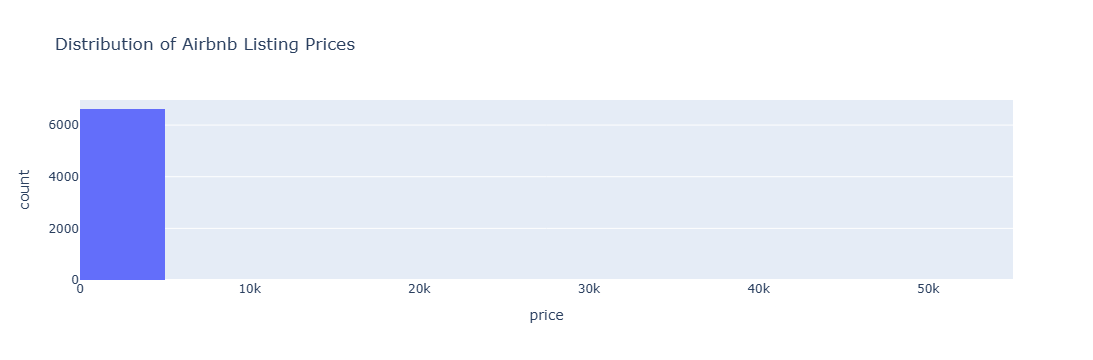

In [17]:
px.histogram(
    df, # you can view the inbetween 0-10k as most of the listing are included in them df[df['price'] <= 1000]
    x='price',
    nbins=10,
    title='Distribution of Airbnb Listing Prices'
)

Most listings are within the lower and middle price ranges, while a relatively small number of luxury properties have higher nightly prices. This right-skewed distribution suggests that premium listings are uncommon but may have a significant influence on average pricing, making median values more representative than the mean.

#### 2. Where is the Money?

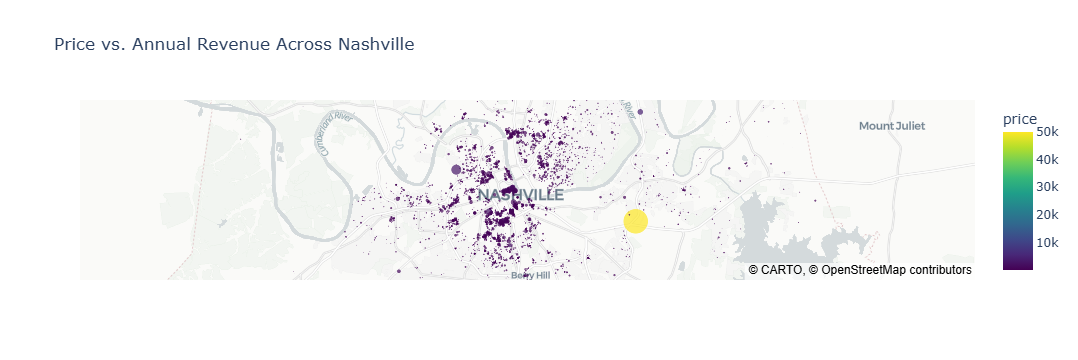

In [108]:
px.scatter_map(
    df,
    lat="latitude",
    lon="longitude",
    color="price",
    size="estimated_annual_revenue",
    color_continuous_scale="Viridis",
    size_max=18,
    zoom=10,
    map_style="carto-positron",
    hover_data=["neighbourhood", "room_type", "price", "estimated_annual_revenue"],
    title="Price vs. Annual Revenue Across Nashville"
)

district 15 is revealed to be a district with premium prices while district 19 generate the most revenue despite lower nightly rates.

#### 3. Price by Room Type 

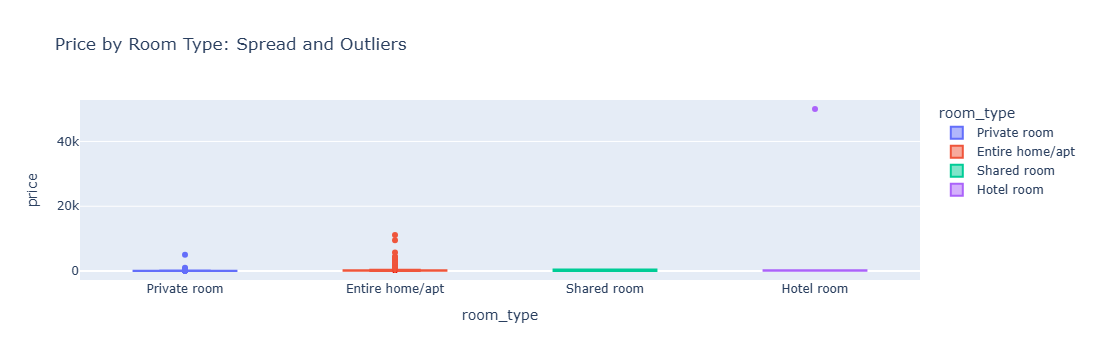

In [53]:
px.box(
    df,
    x="room_type",
    y="price",
    color="room_type",
    points="outliers",
    title="Spread and Outliers"
)

Shows the price spread and outliers for each room type, which seems normally distributed besides hotel room.

#### 4. Highest Earning Neighborhoods

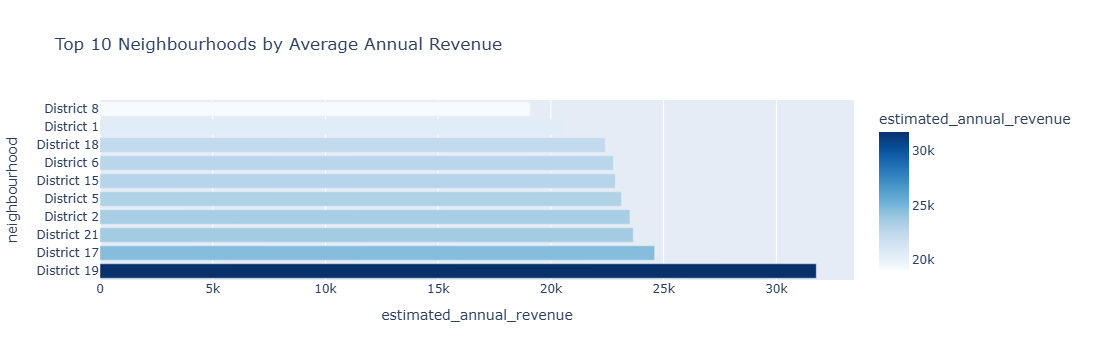

In [39]:
top_neighbourhoods = (
    df.groupby("neighbourhood")["estimated_annual_revenue"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
px.bar(
    top_neighbourhoods,
    x="estimated_annual_revenue",
    y="neighbourhood",
    orientation="h",
    color="estimated_annual_revenue",
    color_continuous_scale="Blues",
    title="Top 10 Neighbourhoods by Average Annual Revenue"
)


Dis.19 are the best investment target for hosts, independent of nightly prices.

#### 5. Do Superhosts Really Earn More? 

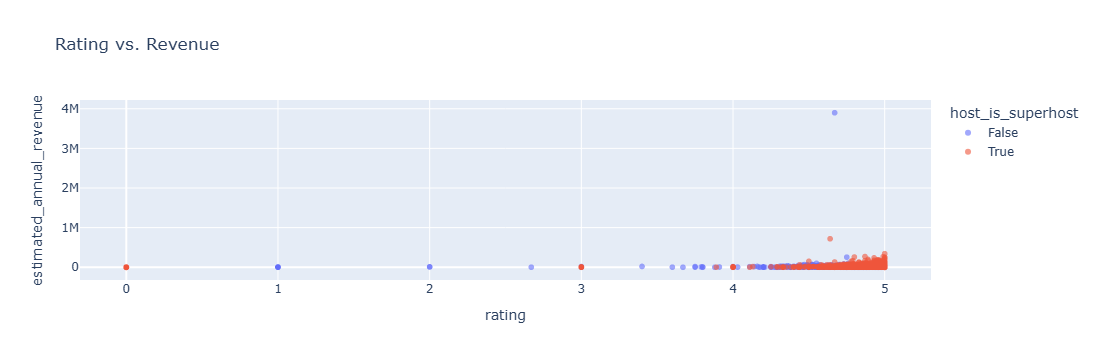

In [61]:
px.scatter(
    df,
    x="rating",
    y="estimated_annual_revenue",
    color="host_is_superhost",
    hover_data=["neighbourhood", "room_type", "price"],
    opacity=0.6,
    title="Rating vs. Revenue"
)

Though being a superhost helps a lot, it doesnt guarnetee revenue or high rating.  

#### 6. The Occupancy Reality Check

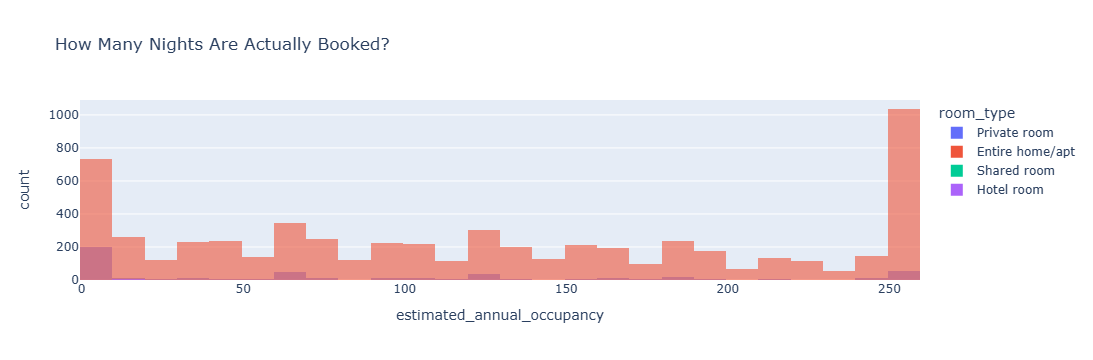

In [107]:
px.histogram(
    df,
    x="estimated_annual_occupancy",
    color="room_type",
    barmode="overlay", 
    nbins=40,
    opacity=0.6,
    title="How Many Nights Are Actually Booked?"
)

the real insight isn't "many listings sit empty" (that's only half true), it's that the market is polarized: ~14% of listings sit near-empty (0–10 nights/year) while ~15.6% hit the modeled ceiling, with comparatively few in the middle. Both extremes are dominated by "Entire home/apt" listings

#### 7. What Actually Drives Price?

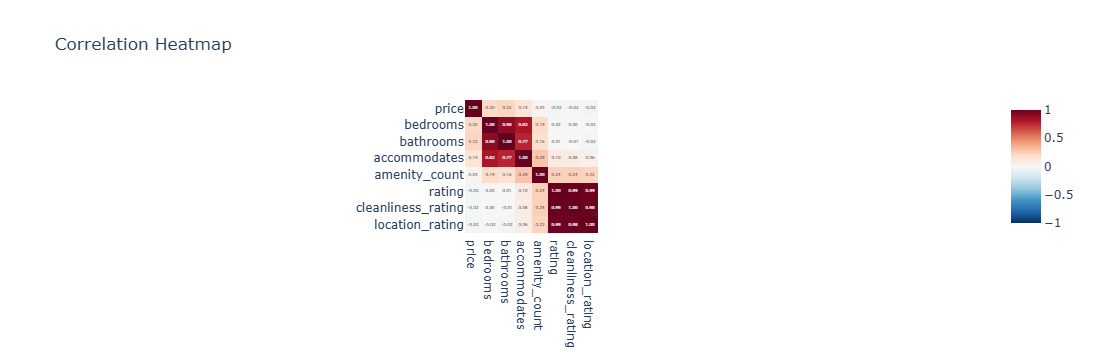

In [79]:
corr_cols = [
    "price", "bedrooms", "bathrooms", "accommodates",
    "amenity_count", "rating", "cleanliness_rating", "location_rating"
]
corr_matrix = df[corr_cols].corr()

px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    title="Correlation Heatmap"
)

only sized-related features like bedroom bathroom and accomodates show any r/ship and even those are very weak.

#### 8. Amenities That Pay Off

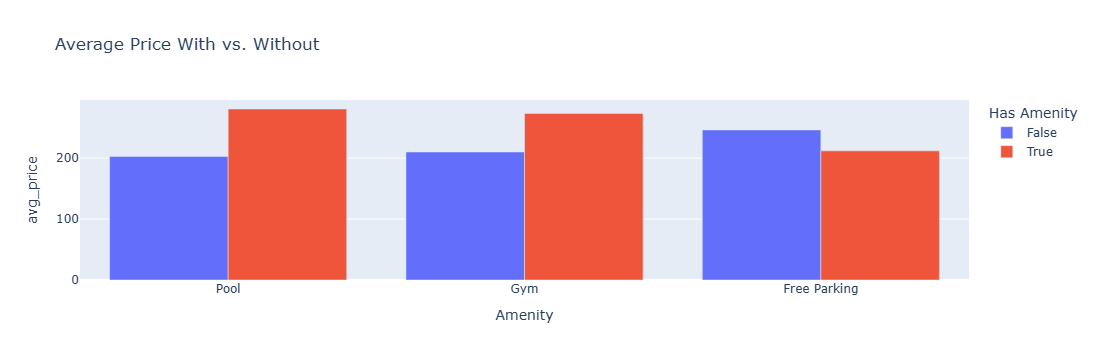

In [80]:
amenity_impact = pd.DataFrame({
    "Pool": df.groupby("has_pool")["price"].mean(),
    "Gym": df.groupby("has_gym")["price"].mean(),
    "Free Parking": df.groupby("has_free_parking")["price"].mean(),
}).reset_index().melt(id_vars="index", var_name="Amenity", value_name="avg_price")
amenity_impact.rename(columns={"index": "Has Amenity"}, inplace=True)

px.bar(
    amenity_impact,
    x="Amenity",
    y="avg_price",
    color="Has Amenity",
    barmode="group",
    title="Average Price With vs. Without"
)

A pool and gym highly justifies a price Bump

#### 9. Experience vs. Response Rate

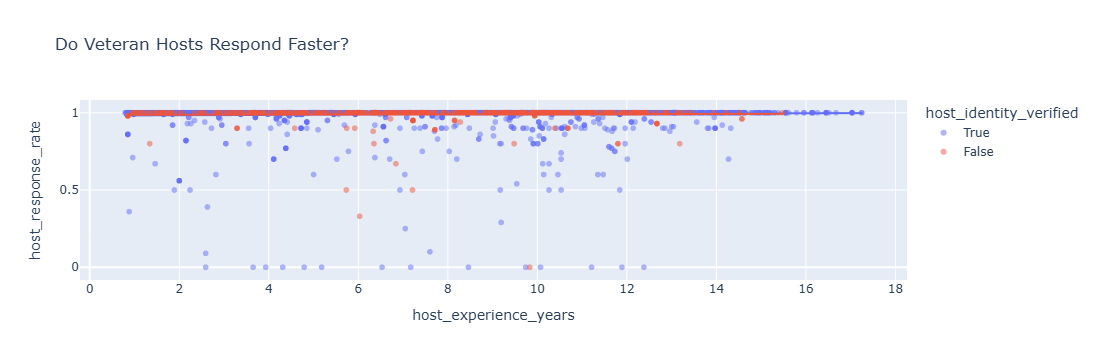

In [81]:
px.scatter(
    df,
    x="host_experience_years",
    y="host_response_rate",
    color="host_identity_verified",
    trendline="ols",
    opacity=0.5,
    title="Do Veteran Hosts Respond Faster?"
)

Being a verifed host doesnt justify for responding faster 

#### 10. Instant Book & Minimum Stay Strategy by District

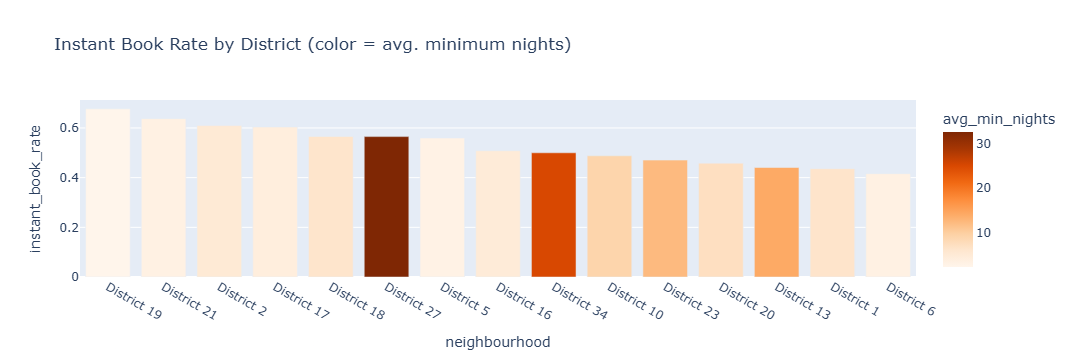

In [105]:
district_strategy = df.groupby("neighbourhood").agg(
    instant_book_rate=("instant_bookable", "mean"),
    avg_min_nights=("minimum_nights", "mean"),
    count_occup=("estimated_annual_occupancy", "count")
).reset_index().sort_values("instant_book_rate", ascending=False).head(15)

px.bar(
    district_strategy,
    x="neighbourhood",
    y="instant_book_rate",
    color="avg_min_nights",
    color_continuous_scale="Oranges",
    hover_data="count_occup",
    title="Instant Book Rate by District (color = avg. minimum nights)"
)

Dist. with high instant book rate tend to have a lesser stay night. as you hover on Dist27 and 34 you can see they have a small listing which let a couple of long minimum-stay outliers drag the average way up. 